### 와인 데이터 딥러닝으로 회귀
202435119 한여원

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import seaborn as sns

In [65]:
# 202435119 한여원
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("D:\hanyeowon\Coding\pythonworks\deep\data\wine.csv")
df = df.drop("Wine", axis=1)


<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
C:\Users\gram\AppData\Local\Temp\ipykernel_2072\3077717863.py:4: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv("D:\hanyeowon\Coding\pythonworks\deep\data\wine.csv")


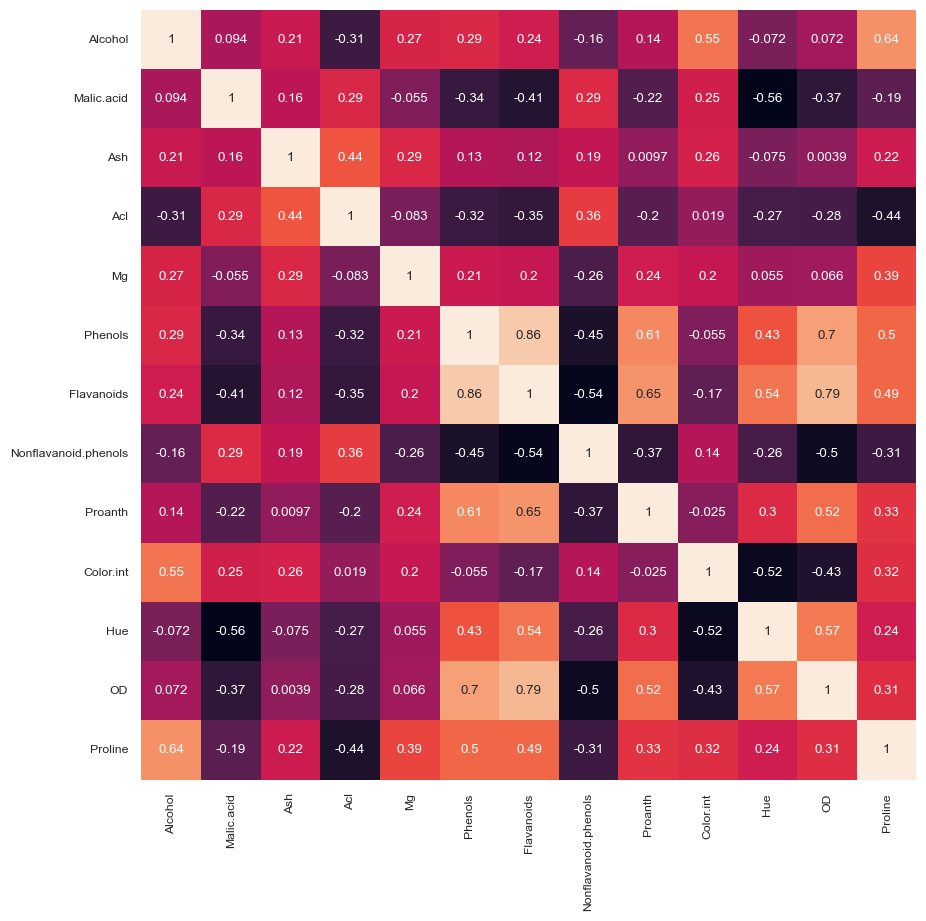

In [66]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [67]:
# print(df)
y = df["Alcohol"] # 알코올을 기준으로 회귀해본다!
X = df.drop("Alcohol", axis=1)
#####
# 회귀 값이 더럽게 안나왔으므로 상관관계가 증명된 데이터만 넣어서 진행하기로 한다 (R2 score <0 라는 처참한 결과값을 보여줌...)
features = [
    "Proline",
    "Color.int",
]
X = X[features]
#####
print(X.dtypes)
X = X.values
print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
scaler = StandardScaler() # 모든 값들을 표준정규분포 형태로 변환
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(y.shape)

Proline        int64
Color.int    float64
dtype: object
0      14.23
1      13.20
2      13.16
3      14.37
4      13.24
       ...  
173    13.71
174    13.40
175    13.27
176    13.17
177    14.13
Name: Alcohol, Length: 178, dtype: float64
(178,)


Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 162.7139 - mse: 162.7139 - val_loss: 151.6058 - val_mse: 151.6058
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 147.4519 - mse: 147.4519 - val_loss: 135.9660 - val_mse: 135.9660
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 128.6300 - mse: 128.6300 - val_loss: 116.0879 - val_mse: 116.0879
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 104.7237 - mse: 104.7237 - val_loss: 90.9869 - val_mse: 90.9869
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 77.4421 - mse: 77.4421 - val_loss: 62.7230 - val_mse: 62.7230
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 49.0574 - mse: 49.0574 - val_loss: 36.4621 - val_mse: 36.4621
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 27.1804 - mse: 27.1804 - val_loss: 19.4203 - val_mse: 19.4203
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 16.7304 - mse: 16.7304 - val_loss: 14.6244 - val_mse: 14.6244
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/s

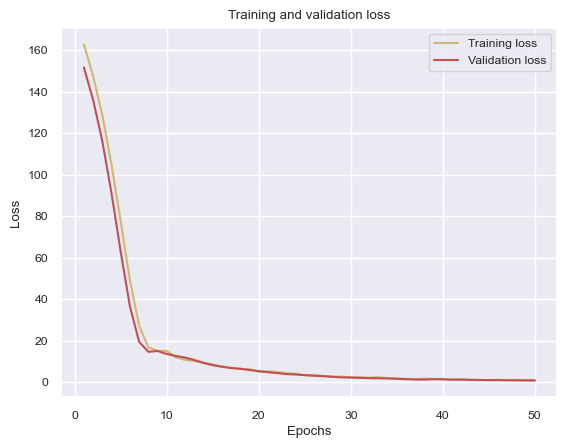

In [68]:
model = models.Sequential([
    layers.Dense(164, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.1),
    layers.Dense(164, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test_scaled)

loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [69]:
print(loss)
print(val_loss)
print(mse)
print(val_mse)


[162.71392822265625, 147.451904296875, 128.63003540039062, 104.72372436523438, 77.44212341308594, 49.05735397338867, 27.180410385131836, 16.73037338256836, 15.138278007507324, 15.051755905151367, 11.991153717041016, 10.753325462341309, 10.145462989807129, 9.2839994430542, 8.594170570373535, 7.454169273376465, 6.973042011260986, 6.3850016593933105, 6.285768508911133, 5.047330856323242, 5.23089075088501, 4.931922912597656, 4.359761714935303, 4.083358287811279, 3.336848497390747, 3.516770601272583, 3.002359628677368, 2.74285888671875, 2.611903667449951, 2.4123339653015137, 2.30322527885437, 2.163785457611084, 2.407144784927368, 1.9130617380142212, 1.8159587383270264, 1.5545437335968018, 1.437081217765808, 1.66628098487854, 1.528721809387207, 1.5096592903137207, 1.322662591934204, 1.455582618713379, 1.1055198907852173, 1.0625742673873901, 0.9733670353889465, 1.201004981994629, 0.9537084102630615, 1.0382152795791626, 1.0232398509979248, 0.8664683103561401]
[151.6057891845703, 135.9659576416

In [70]:
print(y_test.shape)
print(y_pred.shape)
print(y_test)
print(y_pred)

(45,)
(45, 1)
54     13.74
151    12.79
63     12.37
55     13.56
123    13.05
121    11.56
7      14.06
160    12.36
106    12.25
90     12.08
141    13.36
146    13.88
5      14.20
98     12.37
168    13.58
80     12.00
33     13.76
18     14.19
61     12.64
51     13.83
66     13.11
37     13.05
4      13.24
104    12.51
60     12.33
111    12.52
126    12.43
86     12.16
112    11.76
164    13.78
26     13.39
56     14.22
129    12.04
45     14.21
8      14.83
44     13.05
161    13.69
92     12.69
94     11.62
174    13.40
24     13.50
30     13.73
93     12.29
101    12.60
113    11.41
Name: Alcohol, dtype: float64
[[12.64902  ]
 [14.920617 ]
 [12.670627 ]
 [12.917941 ]
 [12.693457 ]
 [12.786173 ]
 [14.103331 ]
 [12.961275 ]
 [12.357963 ]
 [12.551431 ]
 [12.129211 ]
 [12.802722 ]
 [14.814187 ]
 [12.1831   ]
 [12.758382 ]
 [13.192904 ]
 [13.592459 ]
 [16.666212 ]
 [12.813634 ]
 [13.747524 ]
 [12.447223 ]
 [13.125244 ]
 [12.22289  ]
 [12.336257 ]
 [12.296516 ]
 [12.968786 ]
 [12.93

In [71]:
from sklearn.metrics import r2_score

print(f"R2 Score: {r2_score(y_test, y_pred)}")

R2 Score: -0.3572692569848619


In [73]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print(r2_score(y_test, model.predict(X_test_scaled)))

0.5842469683727782


In [75]:
# 알코올은 아무리 해도 거지같이 예측이 힘드므로 다른 피쳐를 가져와보자
y = df["Color.int"] # 이번에 Color.int
X = df.drop("Color.int", axis=1)

print(X.dtypes)
X = X.values
print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
scaler = StandardScaler() # 모든 값들을 표준정규분포 형태로 변환
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(y.shape)

Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object
0       5.64
1       4.38
2       5.68
3       7.80
4       4.32
       ...  
173     7.70
174     7.30
175    10.20
176     9.30
177     9.20
Name: Color.int, Length: 178, dtype: float64
(178,)


Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 30.8978 - mse: 30.8978 - val_loss: 22.2055 - val_mse: 22.2055
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 19.9930 - mse: 19.9930 - val_loss: 14.0560 - val_mse: 14.0560
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11.3835 - mse: 11.3835 - val_loss: 7.5207 - val_mse: 7.5207
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3688 - mse: 6.3688 - val_loss: 4.2190 - val_mse: 4.2190
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3857 - mse: 4.3857 - val_loss: 3.0575 - val_mse: 3.0575
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.0845 - mse: 4.0845 - val_loss: 2.3070 - val_mse: 2.3070
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.3627 - mse: 3.3627 - val_loss: 2.2716 - val_mse: 2.2716
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.9453 - mse: 2.9453 - val_loss: 2.3820 - val_mse: 2.3820
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.5680 - mse: 2.5680 - v

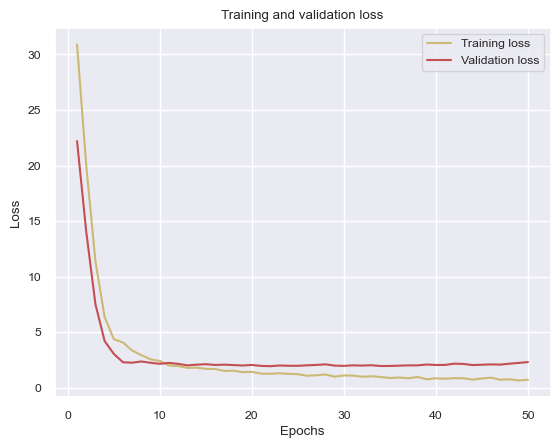

In [76]:
model = models.Sequential([
    layers.Dense(164, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.1),
    layers.Dense(164, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test_scaled)

loss = history.history['loss']
val_loss = history.history['val_loss']
mse = history.history['mse']
val_mse = history.history['val_mse']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print(loss)
print(val_loss)
print(mse)
print(val_mse)
print(y_test.shape)
print(y_pred.shape)
print(y_test)
print(y_pred)

In [ ]:
from sklearn.metrics import r2_score

print(f"R2 Score: {r2_score(y_test, y_pred)}") # Color.int 하니깐 잘됨 0.6이면 나름 아쉽지만 준수한 수준

R2 Score: 0.6735047165869865
